# Day 19: PCA for Feature Compression

## Objective
To reduce high-dimensional data using PCA, analyze variance retention, visualize clusters, and benchmark model performance.

In [1]:
from sklearn.datasets import load_digits

digits = load_digits()
X = digits.data
y = digits.target

print(X.shape)

(1797, 64)


In [2]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X)

print("Variance retained:", sum(pca.explained_variance_ratio_))

Variance retained: 0.2850936482369929


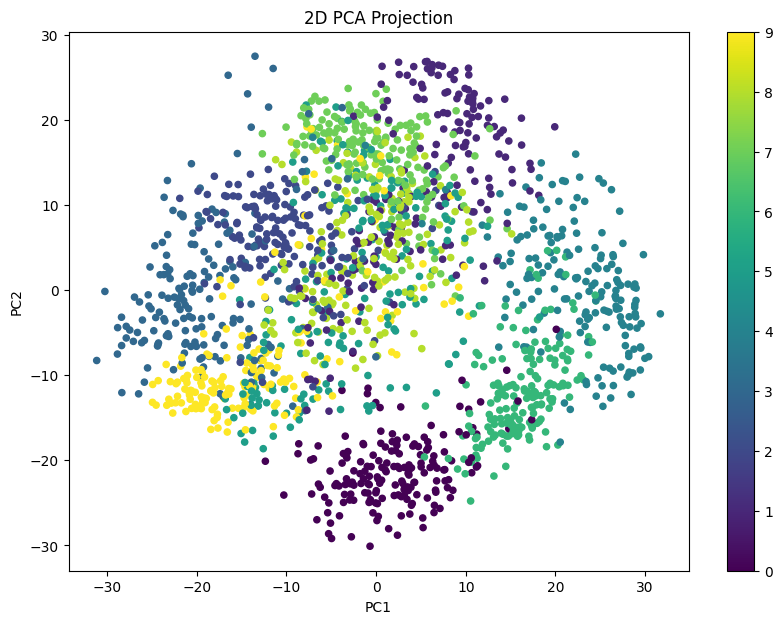

In [3]:
plt.figure(figsize=(10,7))
plt.scatter(X_reduced[:,0], X_reduced[:,1], c=y, cmap='viridis', s=20)
plt.colorbar()
plt.title("2D PCA Projection")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [4]:
import numpy as np

pca_full = PCA().fit(X)
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

n_95 = np.where(cumulative_variance >= 0.95)[0][0] + 1
print("Components for 95% variance:", n_95)

Components for 95% variance: 29


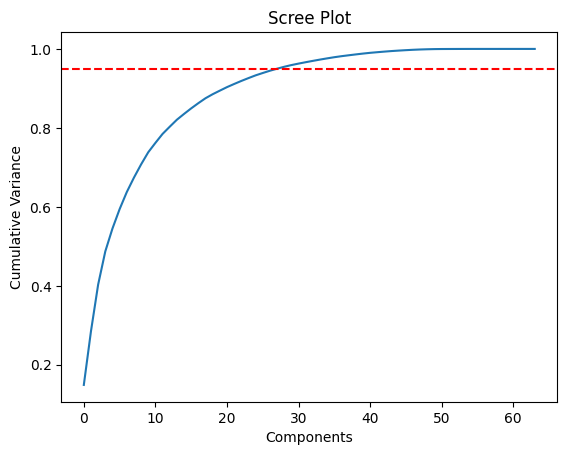

In [5]:
plt.plot(cumulative_variance)
plt.axhline(y=0.95, color='r', linestyle='--')
plt.xlabel("Components")
plt.ylabel("Cumulative Variance")
plt.title("Scree Plot")
plt.show()

In [6]:
from sklearn.linear_model import LogisticRegression
import time

model = LogisticRegression(max_iter=1000)

start = time.time()
model.fit(X, y)
end = time.time()

print("Training time (original):", end - start)

Training time (original): 0.18705534934997559


In [7]:
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X)

model = LogisticRegression(max_iter=1000)

start = time.time()
model.fit(X_pca, y)
end = time.time()

print("Training time (PCA):", end - start)

Training time (PCA): 0.10805177688598633


## Observations

- PCA reduced dimensions from 64 to 2, retaining ~28.51% variance.
- Despite heavy reduction, clusters are still somewhat separable.
- To retain 95% variance, 29 components are required.
- Training on PCA-reduced data is faster compared to original data.

## Reflection

In MeetMux, if we have 500 different interest tags, the data becomes high-dimensional and sparse, which slows down clustering algorithms like K-Means.

Applying PCA reduces these dimensions by keeping only the most important patterns in the data. This removes redundant and less useful features while preserving the core structure.

As a result, K-Means runs faster because distance calculations happen in a smaller feature space. Additionally, clustering becomes more meaningful because noise is reduced.

This leads to faster recommendations and a smoother user experience, especially when scaling to a large number of users.